Step 1: Import Dependencies
```
!pip install pandas numpy matplotlib seaborn scikit-learn wordcloud
```

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import string
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)

import joblib

sns.set(style="whitegrid")
%matplotlib inline

In [19]:
url = 'https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv'
df = pd.read_table(url, header=None, names=['label', 'message'])
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


## Step 3: Summarize the Dataset

In [2]:
import pandas as pd
from sklearn.datasets import load_iris

iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)
df["species"] = iris.target

print("Shape:", df.shape)
df.info()

Shape: (150, 5)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [21]:
# Check for missing/duplicate values
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

# Drop duplicates if any
df = df.drop_duplicates().reset_index(drop=True)
print("Shape after dropping duplicates:", df.shape)

Missing values:
 label      0
message    0
dtype: int64

Duplicate rows: 403
Shape after dropping duplicates: (5169, 2)


## Step 4: Peek at the Data

In [22]:
# First 10 rows
df.head(10)

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


## Step 5: Visualize the Data

/tmp/ipykernel_21652/603393379.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=df, palette='Set2')


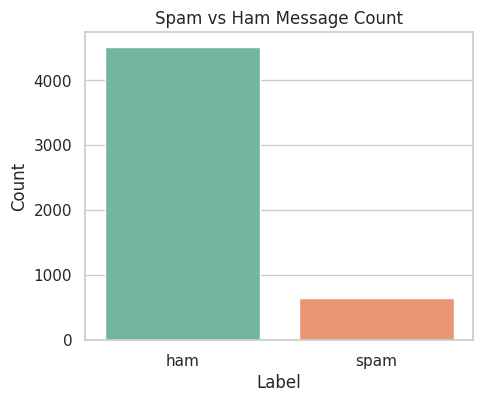

In [24]:
# Class balance bar chart
plt.figure(figsize=(5,4))
sns.countplot(x='label', data=df, palette='Set2')
plt.title('Spam vs Ham Message Count')
plt.xlabel('Label')
plt.ylabel('Count')
plt.show()

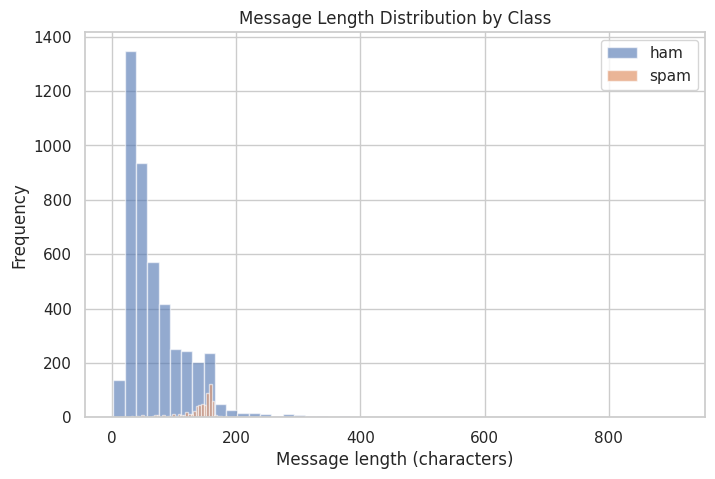

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
ham,4516.0,70.905890,56.715046,2.0,34.0,53.0,91.0,910.0
spam,653.0,137.704441,29.821348,13.0,132.0,148.0,157.0,223.0


In [25]:
# Message length distribution by class
df['message_length'] = df['message'].apply(len)

plt.figure(figsize=(8,5))
df[df['label']=='ham']['message_length'].plot(kind='hist', bins=50, alpha=0.6, label='ham')
df[df['label']=='spam']['message_length'].plot(kind='hist', bins=50, alpha=0.6, label='spam')
plt.legend()
plt.title('Message Length Distribution by Class')
plt.xlabel('Message length (characters)')
plt.show()

df.groupby('label')['message_length'].describe()

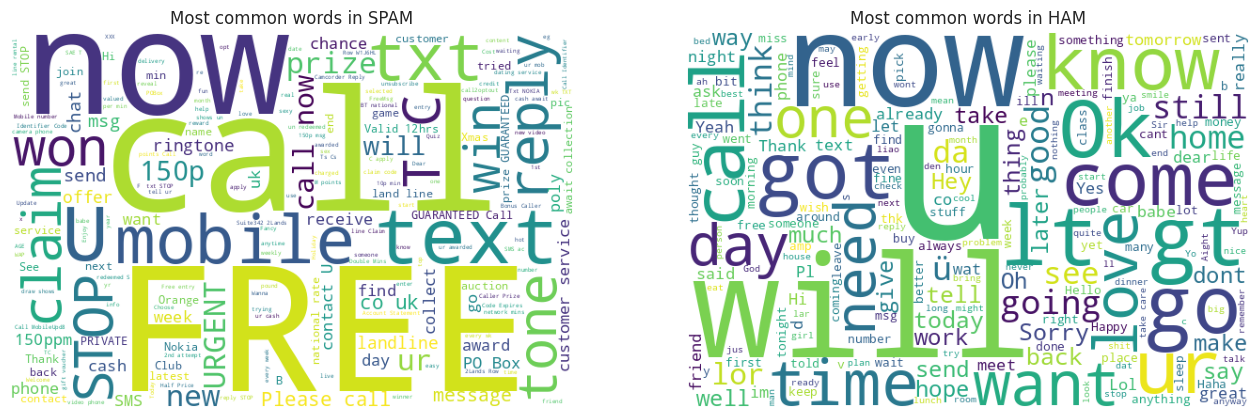

In [26]:
# Optional: word clouds (requires `pip install wordcloud`)
from wordcloud import WordCloud

spam_text = ' '.join(df[df['label']=='spam']['message'])
ham_text = ' '.join(df[df['label']=='ham']['message'])

fig, axes = plt.subplots(1, 2, figsize=(16,6))
axes[0].imshow(WordCloud(width=600, height=400, background_color='white').generate(spam_text))
axes[0].set_title('Most common words in SPAM')
axes[0].axis('off')

axes[1].imshow(WordCloud(width=600, height=400, background_color='white').generate(ham_text))
axes[1].set_title('Most common words in HAM')
axes[1].axis('off')
plt.show()

In [27]:
# Encode labels: ham=0, spam=1
df['label_num'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['message']
y = df['label_num']

# 80% train, 20% test, stratified so both sets keep the same spam/ham ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])

Train size: 4135
Test size: 1034


In [28]:
# TF-IDF vectorization
vectorizer = TfidfVectorizer(stop_words='english', lowercase=True, max_df=0.95, min_df=2)

X_train_vec = vectorizer.fit_transform(X_train)   # fit ONLY on training data
X_test_vec = vectorizer.transform(X_test)          # transform test data using the same vocabulary

print("Vocabulary size:", len(vectorizer.vocabulary_))
print("Train matrix shape:", X_train_vec.shape)

Vocabulary size: 3082
Train matrix shape: (4135, 3082)


In [29]:
models = {
    'Multinomial Naive Bayes': MultinomialNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'Linear SVM': LinearSVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train_vec, y_train)
    preds = model.predict(X_test_vec)
    results[name] = {
        'accuracy': accuracy_score(y_test, preds),
        'precision': precision_score(y_test, preds),
        'recall': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds)
    }

results_df = pd.DataFrame(results).T
results_df

,accuracy,precision,recall,f1
Multinomial Naive Bayes,0.975822,1.000000,0.809160,0.894515
Logistic Regression,0.959381,0.978495,0.694656,0.812500
Linear SVM,0.980658,0.982609,0.862595,0.918699


In [30]:
best_model_name = results_df['f1'].idxmax()
best_model = models[best_model_name]
print(f"Best model: {best_model_name}")

y_pred = best_model.predict(X_test_vec)

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=['ham', 'spam']))

Best model: Linear SVM

Classification report:

              precision    recall  f1-score   support

         ham       0.98      1.00      0.99       903
        spam       0.98      0.86      0.92       131

    accuracy                           0.98      1034
   macro avg       0.98      0.93      0.95      1034
weighted avg       0.98      0.98      0.98      1034



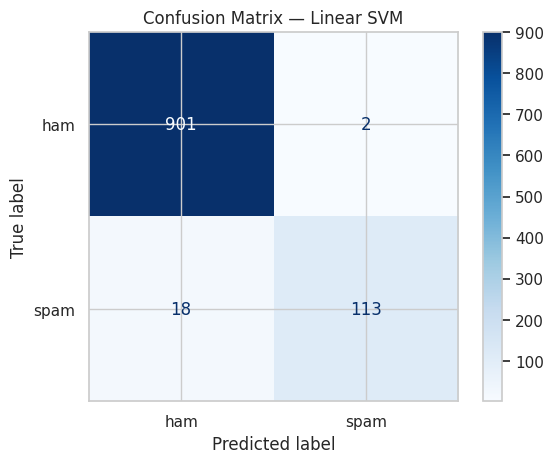

In [31]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['ham', 'spam'])
disp.plot(cmap='Blues')
plt.title(f'Confusion Matrix — {best_model_name}')
plt.show()

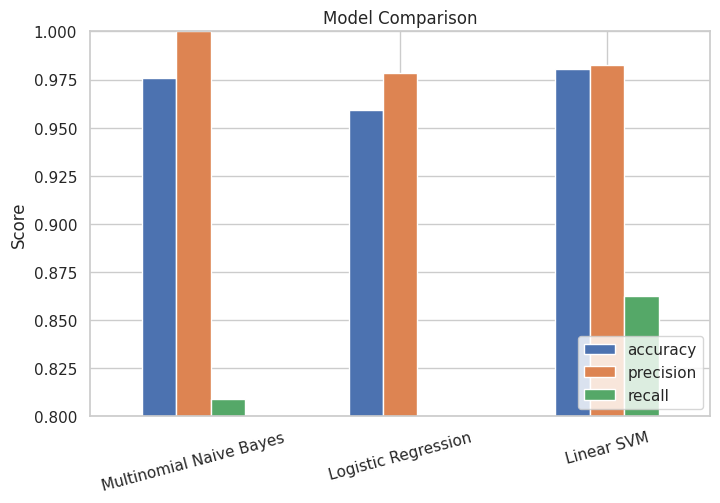

In [32]:
# Bar chart comparing all models on accuracy/precision/recall
results_df[['accuracy', 'precision', 'recall']].plot(kind='bar', figsize=(8,5))
plt.title('Model Comparison')
plt.ylabel('Score')
plt.ylim(0.8, 1.0)
plt.xticks(rotation=15)
plt.legend(loc='lower right')
plt.show()

## Step 9: Make Predictions on New Messages

In [33]:
def predict_message(message, model=best_model, vec=vectorizer):
    vec_msg = vec.transform([message])
    pred = model.predict(vec_msg)[0]
    return 'SPAM' if pred == 1 else 'HAM (genuine)'

sample_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!",
    "Hey, are we still meeting for lunch tomorrow at 1pm?",
    "URGENT: Your account has been suspended. Verify your details immediately to avoid closure.",
    "Can you send me the notes from today's class?"
]

for msg in sample_messages:
    print(f"[{predict_message(msg)}] {msg}")

[SPAM] Congratulations! You've won a $1000 Walmart gift card. Click here to claim now!!!
[HAM (genuine)] Hey, are we still meeting for lunch tomorrow at 1pm?
[SPAM] URGENT: Your account has been suspended. Verify your details immediately to avoid closure.
[HAM (genuine)] Can you send me the notes from today's class?
